<a href="https://colab.research.google.com/github/sowjanyakaranam/heuristic-product-retrieval/blob/m3-final/heuristic_product_retrieval/notebooks/m2_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M3 Experiments: Heuristic Product Retrieval

Colab-ready starter notebook for **CS 57200 – Heuristic Problem Solving (Track B)**.

This notebook demonstrates:
- correct baseline A*
- enhancement 1 (tight heuristic)
- brute-force correctness checks on tiny instances
- baseline vs enhancement experiments
- scaling plots


## 1. Setup

If you opened this notebook directly from GitHub, it is usually **read-only** in Colab.
Click **Copy to Drive** at the top first if you want to edit it.

If the repo is not already present in `/content`, clone it manually in the next cell.


In [1]:
# Uncomment this if the repo is not already cloned in Colab
# !git clone https://github.com/sowjanyakaranam/heuristic-product-retrieval.git


In [22]:
import os
import sys

# Define the expected path of the outermost cloned repository
OUTER_REPO_PATH = "/content/heuristic-product-retrieval"

# Clone the repository if it doesn't exist
if not os.path.exists(OUTER_REPO_PATH):
    print(f"Cloning repository into {OUTER_REPO_PATH}...")
    !git clone https://github.com/sowjanyakaranam/heuristic-product-retrieval.git
else:
    print(f"Repository already cloned at {OUTER_REPO_PATH}.")

# The actual project root (containing 'src', 'requirements.txt') is nested
# This path is based on the repository's structure as observed previously
ACTUAL_PROJECT_ROOT = os.path.join(OUTER_REPO_PATH, "heuristic-product-retrieval", "heuristic_product_retrieval")

# Change current working directory to the actual project root
if os.path.exists(ACTUAL_PROJECT_ROOT):
    os.chdir(ACTUAL_PROJECT_ROOT)
    print(f"Changed current working directory to: {os.getcwd()}")
else:
    print(f"Error: Actual project root not found at {ACTUAL_PROJECT_ROOT}")
    # Attempt to change to OUTER_REPO_PATH and then find the nested path
    if os.path.exists(OUTER_REPO_PATH):
        os.chdir(OUTER_REPO_PATH)
        print(f"Attempted to change to {os.getcwd()} to locate nested project root.")
        nested_part = os.path.join("heuristic-product-retrieval", "heuristic_product_retrieval")
        if os.path.exists(nested_part):
            os.chdir(nested_part)
            print(f"Successfully changed to nested project root: {os.getcwd()}")
            ACTUAL_PROJECT_ROOT = os.getcwd() # Update ACTUAL_PROJECT_ROOT
        else:
            print(f"Error: Could not find nested part {nested_part} in {os.getcwd()}")
            sys.exit(1) # Exit if critical path not found
    else:
        print(f"Fatal Error: {OUTER_REPO_PATH} does not exist even after cloning attempt. Exiting.")
        sys.exit(1)

# Git operations: checkout branch and pull latest changes
print("Performing Git operations...")
!git fetch origin
!git checkout m3-final
!git pull origin m3-final
print(f"Current branch after Git operations: $(git rev-parse --abbrev-ref HEAD)")

# Install dependencies from requirements.txt
REQ_FILE = "requirements.txt"
if os.path.exists(REQ_FILE):
    print(f"Installing dependencies from {REQ_FILE}...")
    !pip install -r {REQ_FILE}
else:
    print(f"Error: {REQ_FILE} not found in {os.getcwd()}. Cannot install dependencies.")

# Add the 'src' directory to sys.path
SRC_PATH = os.path.join(os.getcwd(), "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)
    print(f"Added {SRC_PATH} to sys.path.")
else:
    print(f"{SRC_PATH} already in sys.path.")

print("\nSetup complete.")
print("Current working directory:", os.getcwd())
print("sys.path includes src directory.")


Repository already cloned at /content/heuristic-product-retrieval.
Changed current working directory to: /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval
Performing Git operations...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 573 bytes | 286.00 KiB/s, done.
From https://github.com/sowjanyakaranam/heuristic-product-retrieval
   fccb223..b003632  m3-final   -> origin/m3-final
Already on 'm3-final'
Your branch is behind 'origin/m3-final' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
From https://github.com/sowjanyakaranam/heuristic-product-retrieval
 * branch            m3-final   -> FETCH_HEAD
Updating fccb223..b003632
Fast-forward
 heuristic_product_retrieval/src/data_utils.py | 11 +++++++++++
 1 file changed, 11 insert

In [13]:
import os
import sys

print("--- Environment Check ---")

# Check Current Working Directory
print("Current Working Directory:", os.getcwd())

# List contents of 'src' directory
src_dir = os.path.join(os.getcwd(), "src")
if os.path.exists(src_dir):
    print(f"Contents of {src_dir}:")
    for item in os.listdir(src_dir):
        print(f"  - {item}")
else:
    print(f"Error: 'src' directory not found at {src_dir}")

# Print sys.path
print("\nPython sys.path:")
for p in sys.path:
    print(f"  - {p}")

# Re-run pip install to get full output
print("\n--- Re-running pip install (full output) ---")
!pip install -r requirements.txt

print("\n--- Environment Check Complete ---")


--- Environment Check ---
Current Working Directory: /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval
Contents of /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval/src:
  - heuristics.py
  - viz.py
  - experiments.py
  - __pycache__
  - astar_baseline.py
  - scoring.py
  - data_utils.py

Python sys.path:
  - /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval/src
  - /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval/heuristic-product-retrieval/src
  - /content
  - /env/python
  - /usr/lib/python312.zip
  - /usr/lib/python3.12
  - /usr/lib/python3.12/lib-dynload
  - 
  - /usr/local/lib/python3.12/dist-packages
  - /usr/lib/python3/dist-packages
  - /usr/local/lib/python3.12/dist-packages/IPython/extensions
  - /root/.ipython
  - /content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieva

In [10]:
# This cell's content has been moved to 4kRRydcsRKOf to centralize setup.

In [4]:
# The 'cd' commands are now handled by the previous setup cell, so this is just for confirmation.
!ls

heuristic_product_retrieval  results


In [16]:
!pip install -r requirements.txt

In [11]:
# This cell's content has been moved to 4kRRydcsRKOf to centralize setup.

In [7]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)

print("Created results folders:")
print(os.listdir("results"))

Created results folders:
['tables', 'figures']


## 2. Imports


In [14]:
from data_utils import load_products_csv, filter_by_category
from experiments import run_correctness_test, run_baseline_vs_tight, run_scaling_experiment
from viz import plot_algorithm_comparison, plot_scaling
import pandas as pd


In [12]:
import importlib
from heuristics import tight_heuristic

# Reload the experiments module to ensure changes from git pull are reflected
# This is important if 'experiments' was imported before the correct branch was checked out
import experiments
importlib.reload(experiments)

from experiments import run_weighted_astar_experiment

## 3. Load Sample Data


In [15]:
products = load_products_csv("data/sample_products.csv")
snacks = filter_by_category(products, "Snacks")
query_embedding = (0.22, 0.32, 0.44, 0.25)

print("Total products:", len(products))
print("Snack products:", len(snacks))
snacks[0]


Total products: 60
Snack products: 12


Product(pid='P001', title='Snacks Product 1', category='Snacks', price=29.11, embedding=(0.1718, 0.1441, 0.4741, 0.1316))

## 4. Correctness Tests

These compare A* with brute force on small instances.


In [ ]:
r1 = run_correctness_test(snacks[:8], query_embedding, k=3, lam=0.30)
r2 = run_correctness_test(snacks[:10], query_embedding, k=4, lam=0.30)

bev = filter_by_category(products, "Beverages")[:8]
q_bev = (0.45, 0.34, 0.61, 0.29)
r3 = run_correctness_test(bev, q_bev, k=3, lam=0.30)

df_correctness = pd.DataFrame([r1, r2, r3])
df_correctness


## 5. Experiment 1: Baseline vs Tight Heuristic


In [ ]:
exp1 = [run_baseline_vs_tight(snacks[:12], query_embedding, k=k, lam=0.30) for k in [3, 4, 5]]
df_exp1 = pd.DataFrame(exp1)
df_exp1


In [ ]:
import os

os.makedirs("results/figures", exist_ok=True)
plot_algorithm_comparison(
    labels=[str(x) for x in df_exp1["k"]],
    baseline_vals=df_exp1["baseline_nodes"].tolist(),
    tight_vals=df_exp1["tight_nodes"].tolist(),
    ylabel="Nodes Expanded",
    title="Baseline A* vs Tight Heuristic: Nodes Expanded",
    output_path="results/figures/baseline_vs_tight_nodes.png",
)

## 6. Experiment 2: Scaling Study


In [ ]:
pool = products[:40]
scaling = run_scaling_experiment(pool, query_embedding, sizes=[10, 15, 20, 25], k=4, lam=0.30)
df_scaling = pd.DataFrame(scaling)
df_scaling


In [ ]:
plot_scaling(
    ns=df_scaling["n"].tolist(),
    baseline_vals=df_scaling["baseline_runtime_sec"].tolist(),
    tight_vals=df_scaling["tight_runtime_sec"].tolist(),
    ylabel="Runtime (sec)",
    title="Scaling Study: Runtime vs Candidate Pool Size",
    output_path="results/figures/scaling_runtime.png",
)


M3 Experiment-1

In [17]:
weights = [1.0, 1.2, 1.5, 2.0]

weighted_results = run_weighted_astar_experiment(
    products=snacks[:12],
    query_embedding=query_embedding,
    k=4,
    weights=weights,
    heuristic_fn=tight_heuristic,
    lam=0.30,
)

df_weighted = pd.DataFrame(weighted_results)
df_weighted

,weight,objective,optimal_objective,optimality_gap,nodes_expanded,runtime_sec
0,1.0,2.123202,2.123202,0.0,1466,0.531016
1,1.2,2.123202,2.123202,0.0,1466,0.511585
2,1.5,2.123202,2.123202,0.0,1466,0.456716
3,2.0,2.123202,2.123202,0.0,1466,0.496504


## 7. Save Tables for the Report


In [ ]:
df_correctness.to_csv("results/tables/correctness_tests.csv", index=False)
df_exp1.to_csv("results/tables/exp1_baseline_vs_tight.csv", index=False)
df_scaling.to_csv("results/tables/exp2_scaling.csv", index=False)
print("Saved tables and figures under results/.")


In [ ]:
df_correctness.to_csv("results/tables/correctness_tests.csv", index=False)
df_exp1.to_csv("results/tables/exp1_baseline_vs_tight.csv", index=False)
df_scaling.to_csv("results/tables/exp2_scaling.csv", index=False)

print("Tables saved.")

In [ ]:
k_sensitivity = [run_baseline_vs_tight(snacks[:12], query_embedding, k=k, lam=0.30) for k in [2, 3, 4, 5]]
df_k = pd.DataFrame(k_sensitivity)
df_k

In [ ]:
plot_scaling(
    ns=df_k["k"].tolist(),
    baseline_vals=df_k["baseline_nodes"].tolist(),
    tight_vals=df_k["tight_nodes"].tolist(),
    ylabel="Nodes Expanded",
    title="Sensitivity to K: Nodes Expanded vs K",
    output_path="results/figures/k_sensitivity_nodes.png",
)

In [ ]:
df_k.to_csv("results/tables/exp3_k_sensitivity.csv", index=False)

M3 Experiment-1

In [23]:
import importlib
import data_utils

importlib.reload(data_utils)

<module 'data_utils' from '/content/heuristic-product-retrieval/heuristic-product-retrieval/heuristic_product_retrieval/src/data_utils.py'>

In [24]:
from data_utils import top_m_by_relevance
from scoring import relevance
from astar_baseline import astar_search

ms = [8, 10, 12]

results_topm = []

for m in ms:
    filtered = top_m_by_relevance(snacks, query_embedding, m, relevance)

    res = astar_search(
        filtered,
        query_embedding,
        k=4,
        heuristic_fn=tight_heuristic
    )

    results_topm.append({
        "M": m,
        "objective": res["objective"],
        "nodes": res["nodes_expanded"],
        "runtime": res["runtime_sec"],
    })

df_topm = pd.DataFrame(results_topm)
df_topm

,M,objective,nodes,runtime
0,8,2.123202,402,0.128405
1,10,2.123202,822,0.361992
2,12,2.123202,1466,0.908372


In [25]:
df_topm.to_csv("results/tables/exp5_topm.csv", index=False)

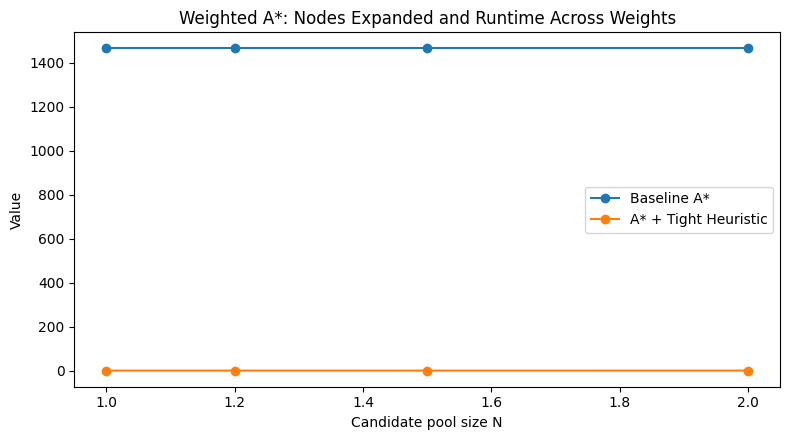

In [26]:
plot_scaling(
    ns=df_weighted["weight"].tolist(),
    baseline_vals=df_weighted["nodes_expanded"].tolist(),
    tight_vals=df_weighted["runtime_sec"].tolist(),
    ylabel="Value",
    title="Weighted A*: Nodes Expanded and Runtime Across Weights",
    output_path="results/figures/weighted_astar_tradeoff.png",
)

M3 Experiment-2

In [33]:
from data_utils import top_m_by_relevance
from scoring import relevance
from astar_baseline import astar_search

ms = [8, 10, 12]
results_topm = []

for m in ms:
    filtered = top_m_by_relevance(snacks, query_embedding, m, relevance)
    res = astar_search(filtered, query_embedding, k=4, heuristic_fn=tight_heuristic)

    results_topm.append({
        "M": m,
        "objective": res["objective"],
        "nodes": res["nodes_expanded"],
        "runtime": res["runtime_sec"],
    })

df_topm = pd.DataFrame(results_topm)
df_topm

,M,objective,nodes,runtime
0,8,2.123202,402,0.064986
1,10,2.123202,822,0.300183
2,12,2.123202,1466,0.411538


In [28]:
df_topm.to_csv("results/tables/exp5_topm.csv", index=False)

In [29]:
!find results -maxdepth 2 -type f | sort

results/figures/weighted_astar_tradeoff.png
results/tables/exp5_topm.csv


## 8. Next Steps

- Replace `data/sample_products.csv` with cleaned real category data
- Replace synthetic embeddings with Sentence-BERT embeddings
- Add a third experiment varying `K` or `lambda`
- Save results and use them directly in M2 report


In [ ]:
# Inspect the contents of experiments.py to check for 'run_weighted_astar_experiment'
!cat src/experiments.py

Amazon DataSet - M3 Experiment 3

In [34]:
!pip install sentence-transformers

In [36]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"karanamsowjanya","key":"fa98d3f3e6bf6dd16b2daec3ed8d9d98"}'}

In [37]:
!ls

data			     kaggle.json  README.md	    results
heuristic-product-retrieval  notebooks	  requirements.txt  src


In [38]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [39]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          16309        357                1  
hassanali789/world-happiness-report-2026-official-rankings          World Happiness Report 2026 — Official Rankings           3311  2026-04-29 02:35:36.353000            616         31                1  
patelris/steam-top-1495-games-dataset                               🎮 Steam Dataset for Recommendation & Prediction         345215  2026-04-29 13:56:22.557000            587         28

In [40]:
!kaggle datasets download -d kashnitsky/amazon-products-dataset

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [41]:
!kaggle datasets download -d promptcloud/amazon-product-dataset-2020
!unzip -o amazon-product-dataset-2020.zip -d data

Dataset URL: https://www.kaggle.com/datasets/promptcloud/amazon-product-dataset-2020
License(s): CC0-1.0
100% 5.37M/5.37M [00:01<00:00, 4.61MB/s]

Archive:  amazon-product-dataset-2020.zip
  inflating: data/home/sdf/marketing_sample_for_amazon_com-ecommerce__20200101_20200131__10k_data.csv  


In [42]:
!find data -maxdepth 2 -type f | head -20

data/sample_products.csv


In [43]:
csv_path = "data/home/sdf/marketing_sample_for_amazon_com-ecommerce__20200101_20200131__10k_data.csv"

import pandas as pd
df_kaggle = pd.read_csv(csv_path)
df_kaggle.head()

,Uniq Id,Product Name,Brand Name,Asin,Category,Upc Ean Code,List Price,Selling Price,Quantity,Model Number,...,Product Url,Stock,Product Details,Dimensions,Color,Ingredients,Direction To Use,Is Amazon Seller,Size Quantity Variant,Product Description
0,4c69b61db1fc16e7013b43fc926e502d,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",NaN,NaN,Sports & Outdoors | Outdoor Recreation | Skate...,NaN,NaN,$237.68,NaN,NaN,...,https://www.amazon.com/DB-Longboards-CoreFlex-...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
1,66d49bbed043f5be260fa9f7fbff5957,"Electronic Snap Circuits Mini Kits Classpack, ...",NaN,NaN,Toys & Games | Learning & Education | Science ...,NaN,NaN,$99.95,NaN,55324,...,https://www.amazon.com/Electronic-Circuits-Cla...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
2,2c55cae269aebf53838484b0d7dd931a,3Doodler Create Flexy 3D Printing Filament Ref...,NaN,NaN,Toys & Games | Arts & Crafts | Craft Kits,NaN,NaN,$34.99,NaN,NaN,...,https://www.amazon.com/3Doodler-Plastic-Innova...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
3,18018b6bc416dab347b1b7db79994afa,Guillow Airplane Design Studio with Travel Cas...,NaN,NaN,Toys & Games | Hobbies | Models & Model Kits |...,NaN,NaN,$28.91,NaN,142,...,https://www.amazon.com/Guillow-Airplane-Design...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
4,e04b990e95bf73bbe6a3fa09785d7cd0,Woodstock- Collage 500 pc Puzzle,NaN,NaN,Toys & Games | Puzzles | Jigsaw Puzzles,NaN,NaN,$17.49,NaN,62151,...,https://www.amazon.com/Woodstock-Collage-500-p...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN


In [44]:
df_kaggle.columns

Index(['Uniq Id', 'Product Name', 'Brand Name', 'Asin', 'Category',
       'Upc Ean Code', 'List Price', 'Selling Price', 'Quantity',
       'Model Number', 'About Product', 'Product Specification',
       'Technical Details', 'Shipping Weight', 'Product Dimensions', 'Image',
       'Variants', 'Sku', 'Product Url', 'Stock', 'Product Details',
       'Dimensions', 'Color', 'Ingredients', 'Direction To Use',
       'Is Amazon Seller', 'Size Quantity Variant', 'Product Description'],
      dtype='object')

In [45]:
# Pick likely useful columns after inspecting names
df_kaggle = df_kaggle.dropna(subset=["Product Name"])
df_kaggle = df_kaggle.head(300)

df_real = pd.DataFrame({
    "product_id": df_kaggle.index.astype(str),
    "title": df_kaggle["Product Name"].astype(str),
    "category": df_kaggle["Category"].astype(str) if "Category" in df_kaggle.columns else "AmazonProducts",
    "price": 1.0
})

df_real.head()

,product_id,title,category,price
0,0,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",Sports & Outdoors | Outdoor Recreation | Skate...,1.0
1,1,"Electronic Snap Circuits Mini Kits Classpack, ...",Toys & Games | Learning & Education | Science ...,1.0
2,2,3Doodler Create Flexy 3D Printing Filament Ref...,Toys & Games | Arts & Crafts | Craft Kits,1.0
3,3,Guillow Airplane Design Studio with Travel Cas...,Toys & Games | Hobbies | Models & Model Kits |...,1.0
4,4,Woodstock- Collage 500 pc Puzzle,Toys & Games | Puzzles | Jigsaw Puzzles,1.0


In [46]:
df_kaggle.columns.tolist()

['Uniq Id',
 'Product Name',
 'Brand Name',
 'Asin',
 'Category',
 'Upc Ean Code',
 'List Price',
 'Selling Price',
 'Quantity',
 'Model Number',
 'About Product',
 'Product Specification',
 'Technical Details',
 'Shipping Weight',
 'Product Dimensions',
 'Image',
 'Variants',
 'Sku',
 'Product Url',
 'Stock',
 'Product Details',
 'Dimensions',
 'Color',
 'Ingredients',
 'Direction To Use',
 'Is Amazon Seller',
 'Size Quantity Variant',
 'Product Description']

In [47]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df_real["title"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

df_real["embedding"] = [
    "|".join(map(str, emb.tolist()))
    for emb in embeddings
]

df_real.to_csv("data/real_products.csv", index=False)
df_real.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

,product_id,title,category,price,embedding
0,0,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",Sports & Outdoors | Outdoor Recreation | Skate...,1.0,0.018761085346341133|-0.07468325644731522|-0.0...
1,1,"Electronic Snap Circuits Mini Kits Classpack, ...",Toys & Games | Learning & Education | Science ...,1.0,-0.030006036162376404|0.03975541889667511|0.00...
2,2,3Doodler Create Flexy 3D Printing Filament Ref...,Toys & Games | Arts & Crafts | Craft Kits,1.0,-0.10355568677186966|-0.022916583344340324|-0....
3,3,Guillow Airplane Design Studio with Travel Cas...,Toys & Games | Hobbies | Models & Model Kits |...,1.0,0.0288090743124485|0.04979822039604187|-0.0341...
4,4,Woodstock- Collage 500 pc Puzzle,Toys & Games | Puzzles | Jigsaw Puzzles,1.0,-0.025942735373973846|0.05594734475016594|-0.0...


In [48]:
products_real = load_products_csv("data/real_products.csv")

query = "healthy protein snacks"
query_embedding_real = model.encode(query, normalize_embeddings=True).tolist()

filtered = top_m_by_relevance(
    products_real,
    tuple(query_embedding_real),
    m=20,
    scoring_fn=relevance
)

res_real = astar_search(
    filtered,
    tuple(query_embedding_real),
    k=4,
    heuristic_fn=tight_heuristic,
    lam=0.30
)

res_real

{'selected': [Product(pid='157', title='Nuts', category='Toys & Games | Games & Accessories', price=1.0, embedding=(-0.02412496507167816, 0.03490745648741722, 0.026679666712880135, 0.06061834841966629, -0.019242985174059868, -0.03470654785633087, 0.08044766634702682, 0.06888603419065475, 0.03016010858118534, 0.01955999806523323, 0.0021660567726939917, 0.009025423787534237, 0.037137363106012344, -0.05810507386922836, -0.009895524941384792, -0.020673394203186035, 0.045066893100738525, -0.003938314039260149, -0.07881894707679749, -0.08169753849506378, 0.020866334438323975, -6.650400609942153e-05, -0.01160792913287878, -0.02194555103778839, 0.009050487540662289, 0.08259948343038559, 0.027510685846209526, 0.046714432537555695, 0.001075112377293408, -0.06080743297934532, 0.01785055547952652, -0.018807528540492058, 0.03288213536143303, 0.02277444116771221, -0.03669457510113716, -0.002388644963502884, -0.03810214251279831, -0.04563150554895401, 0.03284876421093941, -0.02541257254779339, 0.0420

In [49]:
df_real_exp = pd.DataFrame([{
    "dataset": "Kaggle Amazon Product Dataset 2020",
    "query": query,
    "candidate_pool_m": 20,
    "k": 4,
    "objective": res_real["objective"],
    "nodes_expanded": res_real["nodes_expanded"],
    "runtime_sec": res_real["runtime_sec"]
}])

df_real_exp.to_csv("results/tables/exp6_real_amazon_case_study.csv", index=False)
df_real_exp

,dataset,query,candidate_pool_m,k,objective,nodes_expanded,runtime_sec
0,Kaggle Amazon Product Dataset 2020,healthy protein snacks,20,4,0.857667,2742,49.899676


In [51]:
selected_real = pd.DataFrame([{
    "product_id": p.pid,
    "title": p.title,
    "category": p.category,
    "price": p.price
} for p in res_real["selected"]])

selected_real.to_csv("results/tables/exp6_selected_real_products.csv", index=False)
selected_real

,product_id,title,category,price
0,157,Nuts,Toys & Games | Games & Accessories,1.0
1,197,Pro Series CLM-16 Red Plastic Scoring Pills fo...,nan,1.0
2,271,"Wild Republic Mountain Goat Plush, Stuffed Ani...",Toys & Games | Stuffed Animals & Plush Toys | ...,1.0
3,60,Great Eastern Entertainment Boys Attack On Tit...,"Clothing, Shoes & Jewelry | Men | Accessories ...",1.0


In [52]:
!find results -maxdepth 2 -type f | sort

results/figures/weighted_astar_tradeoff.png
results/tables/exp5_topm.csv
results/tables/exp6_real_amazon_case_study.csv
results/tables/exp6_selected_real_products.csv


In [54]:
print(df_topm)

    M  objective  nodes   runtime
0   8   2.123202    402  0.064986
1  10   2.123202    822  0.300183
2  12   2.123202   1466  0.411538


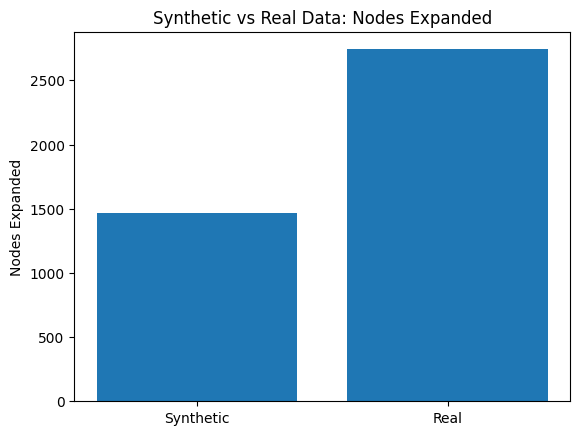

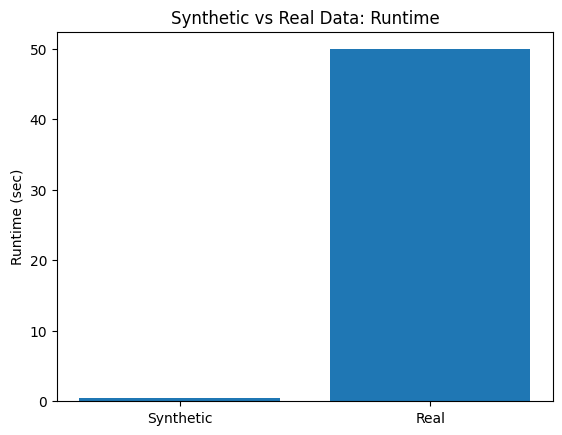

In [55]:
import matplotlib.pyplot as plt

# Synthetic (use one of your earlier experiments, e.g., scaling or baseline)
synthetic_nodes = df_topm.iloc[-1]["nodes"]
synthetic_runtime = df_topm.iloc[-1]["runtime"]

# Real data
real_nodes = res_real["nodes_expanded"]
real_runtime = res_real["runtime_sec"]

labels = ["Synthetic", "Real"]

nodes = [synthetic_nodes, real_nodes]
runtime = [synthetic_runtime, real_runtime]

# Plot nodes
plt.figure()
plt.bar(labels, nodes)
plt.ylabel("Nodes Expanded")
plt.title("Synthetic vs Real Data: Nodes Expanded")
plt.savefig("results/figures/real_vs_synthetic_nodes.png")
plt.show()

# Plot runtime
plt.figure()
plt.bar(labels, runtime)
plt.ylabel("Runtime (sec)")
plt.title("Synthetic vs Real Data: Runtime")
plt.savefig("results/figures/real_vs_synthetic_runtime.png")
plt.show()

In [56]:
!find results/figures

results/figures
results/figures/real_vs_synthetic_nodes.png
results/figures/weighted_astar_tradeoff.png
results/figures/real_vs_synthetic_runtime.png


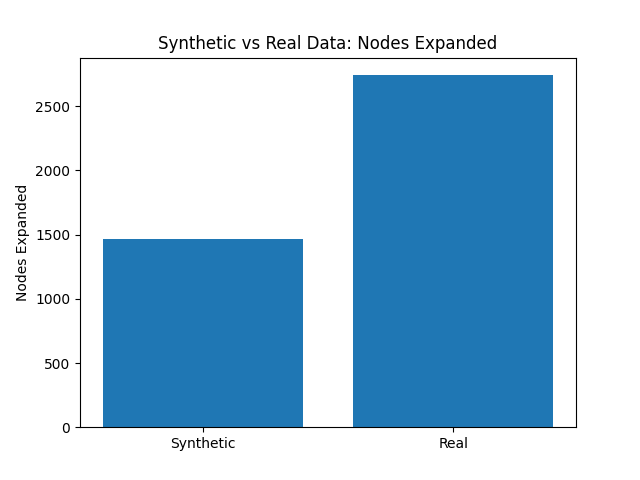

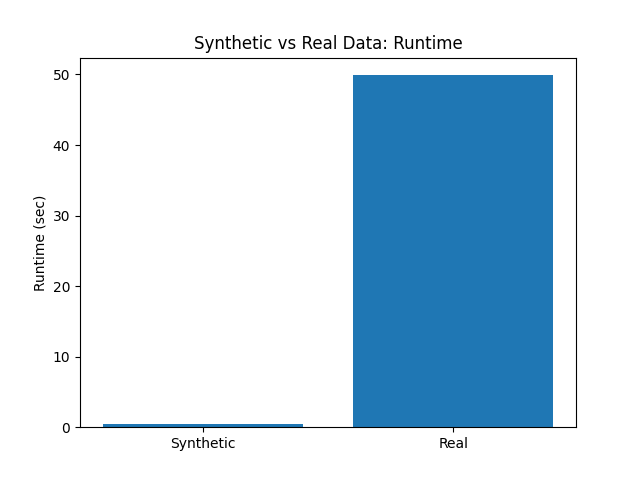

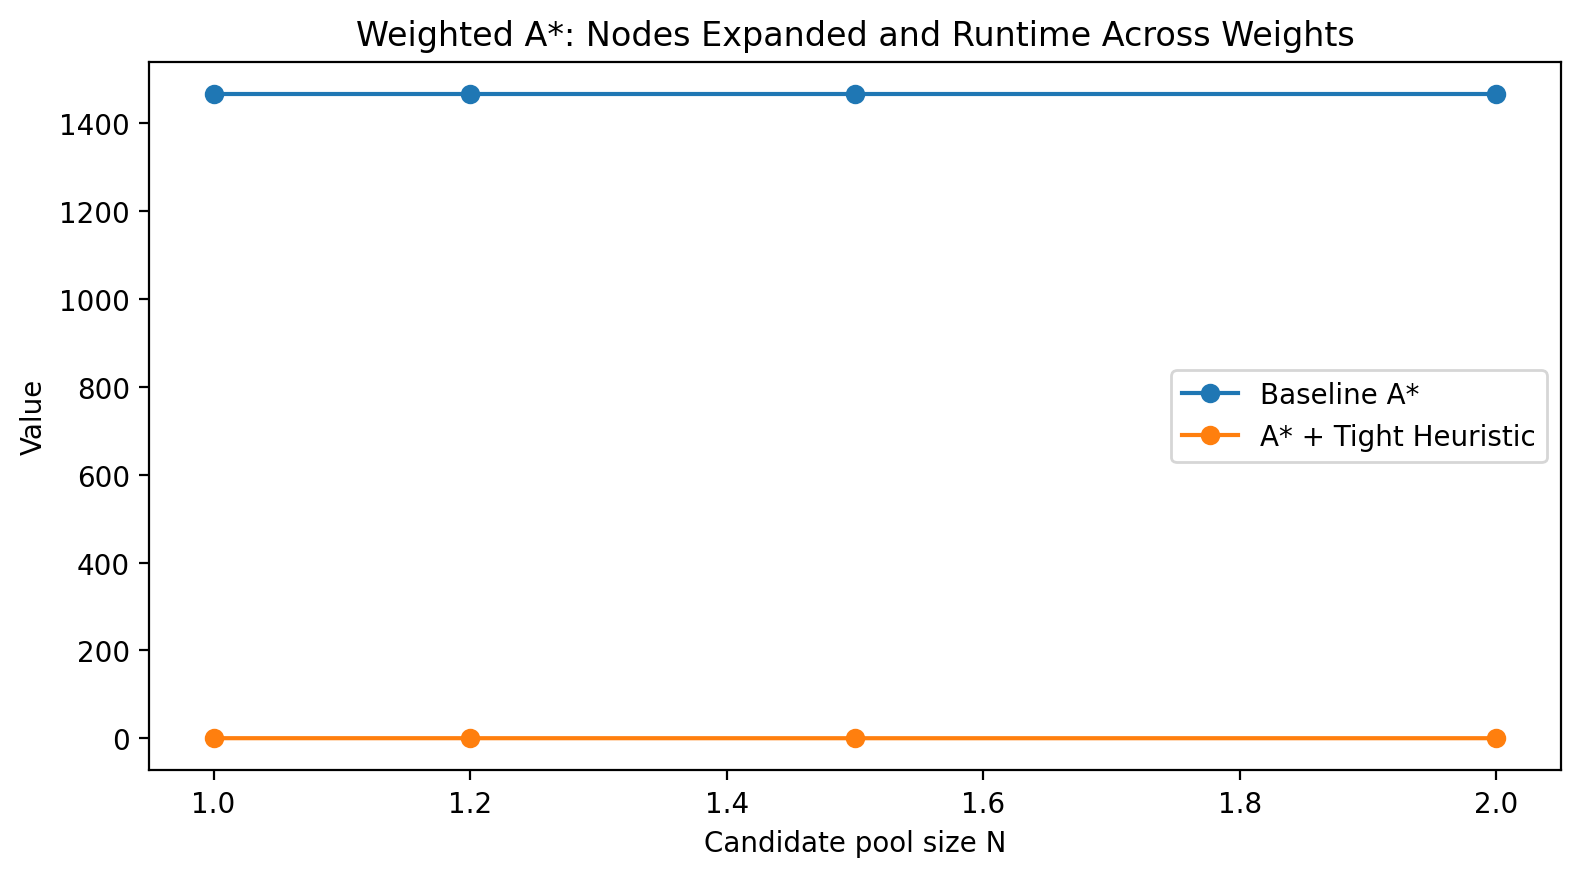

In [57]:
from IPython.display import Image, display

display(Image("results/figures/real_vs_synthetic_nodes.png"))
display(Image("results/figures/real_vs_synthetic_runtime.png"))
display(Image("results/figures/weighted_astar_tradeoff.png"))

In [63]:
!find results -maxdepth 2 -type f | sort

results/figures/real_vs_synthetic_nodes.png
results/figures/real_vs_synthetic_runtime.png
results/figures/weighted_astar_tradeoff.png
results/tables/exp5_topm.csv
results/tables/exp6_real_amazon_case_study.csv
results/tables/exp6_selected_real_products.csv
